In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [4]:
list_AC_stark_vals=[np.float64(-0.06854670085965597), np.float64(-0.0791553748461747), np.float64(-0.09052059521500729), np.float64(-0.10284236196615382), np.float64(-0.11592067509961422), np.float64(-0.12985553461538857), np.float64(-0.14474694051347667), np.float64(-0.16039489279387883), np.float64(-0.17729939145659485), np.float64(-0.19496043650162476), np.float64(-0.21367802792896848), np.float64(-0.2334521657386262), np.float64(-0.2542828499305977), np.float64(-0.2759700805048832), np.float64(-0.2989138574614825), np.float64(-0.3229141808003959), np.float64(-0.34777105052162305), np.float64(-0.373784466625164), np.float64(-0.40095442911101903), np.float64(-0.4288809379791878)]
list_AC_stark_vals=[np.float64(-0.06854670085959402), np.float64(-0.07915537484610222), np.float64(-0.09052059521492348), np.float64(-0.10274236196605781), np.float64(-0.11582067509950522), np.float64(-0.12985553461526572), np.float64(-0.14464694051333923), np.float64(-0.1602948927937259), np.float64(-0.17719939145642558), np.float64(-0.19486043650143847), np.float64(-0.2135780279287643), np.float64(-0.23325216573840316), np.float64(-0.25398284993035514), np.float64(-0.2757700805046203), np.float64(-0.2985138574611985), np.float64(-0.32241418080008977), np.float64(-0.3475710505212941), np.float64(-0.3731844666248115), np.float64(-0.400254429110642), np.float64(-0.4282809379787856)]

list_ef_AC_stark_vals=[np.float64(5.862378319584177), np.float64(6.291660027196749), np.float64(6.720941734809321), np.float64(7.1502234424218925), np.float64(7.579505150034464), np.float64(8.008786857647035), np.float64(8.438068565259606), np.float64(8.867350272872178), np.float64(9.296631980484749), np.float64(9.725913688097322), np.float64(10.155195395709892), np.float64(10.584477103322463), np.float64(11.013758810935034), np.float64(11.443040518547605), np.float64(11.872322226160177), np.float64(12.30160393377275), np.float64(12.73088564138532), np.float64(13.160167348997891), np.float64(13.589449056610464), np.float64(14.018730764223035)]


## Simulaatio

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [6]:
def find_params(f_d,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 8:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef/3+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=5,drag=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef/3+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=2,drag=True)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_d-ω_q/3 (GHz)")
    plt.ylabel("Suurin f-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

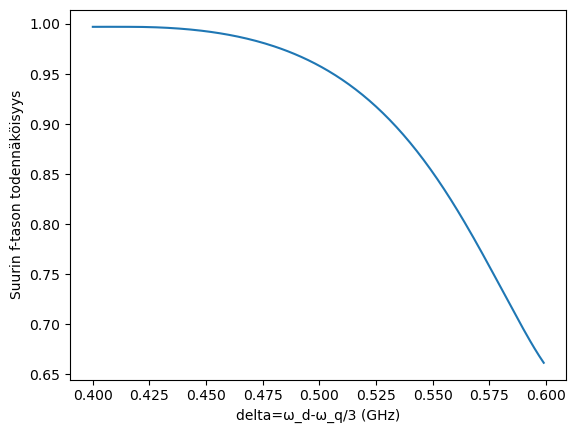

Amplitudi (GHz): 5.862378319584177
AC-stark siirtymä (GHz): 0.404
E-tason suurin todennäköisyys: 0.9989027111405493
Pulssin pituus (ns): 319.400691583002
Rabi-taajuus (fourier):  0.002185167692922755


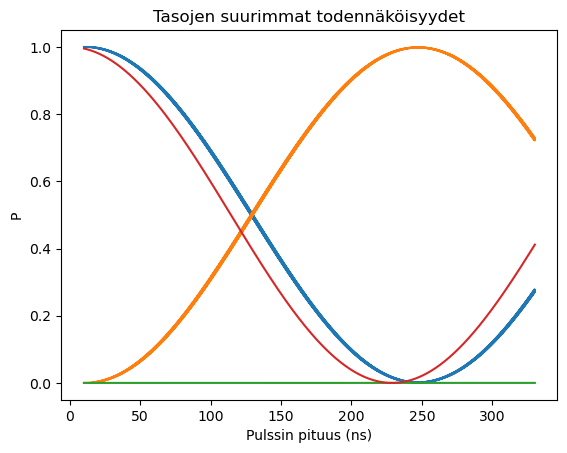

---------------------------------------------


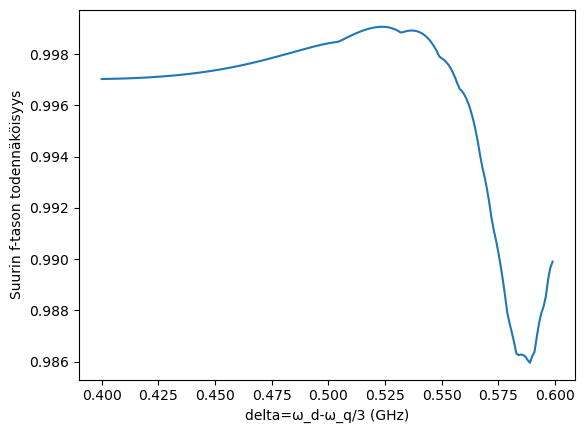

Amplitudi (GHz): 6.291660027196749
AC-stark siirtymä (GHz): 0.524
E-tason suurin todennäköisyys: 0.9993895170677627
Pulssin pituus (ns): 207.81812844429578
Rabi-taajuus (fourier):  0.0024583838483561316


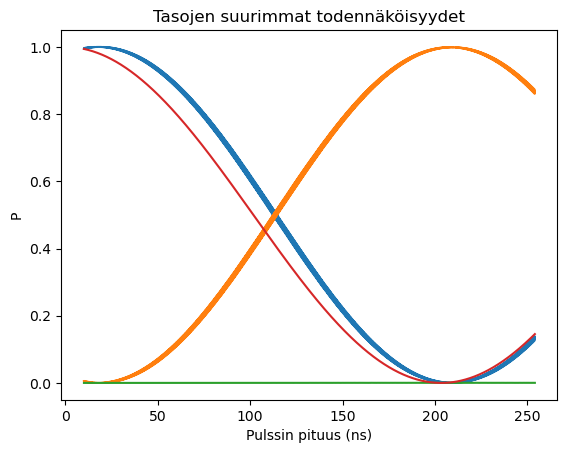

---------------------------------------------


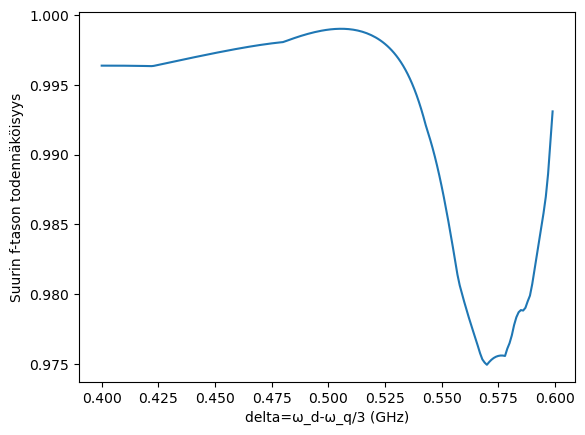

Amplitudi (GHz): 6.720941734809321
AC-stark siirtymä (GHz): 0.506
E-tason suurin todennäköisyys: 0.9992099337328575
Pulssin pituus (ns): 181.92334746905524
Rabi-taajuus (fourier):  0.0030942054261295865


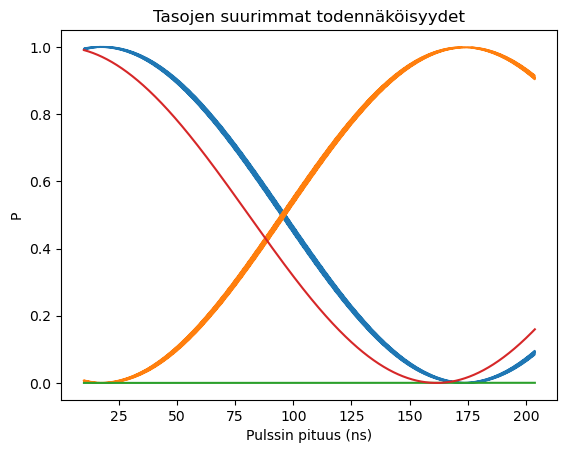

---------------------------------------------


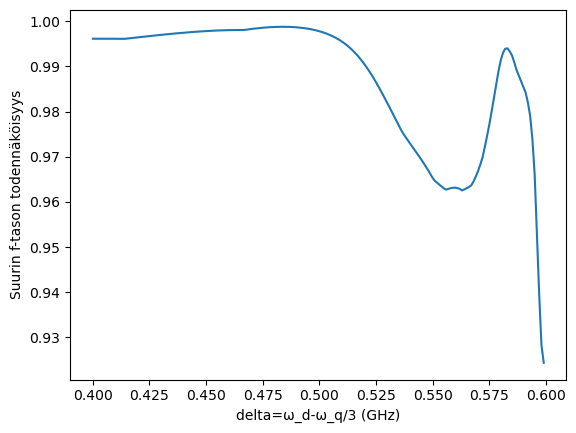

Amplitudi (GHz): 7.1502234424218925
AC-stark siirtymä (GHz): 0.484
E-tason suurin todennäköisyys: 0.9989610158908179
Pulssin pituus (ns): 152.2304363672856
Rabi-taajuus (fourier):  0.0037933515126451155


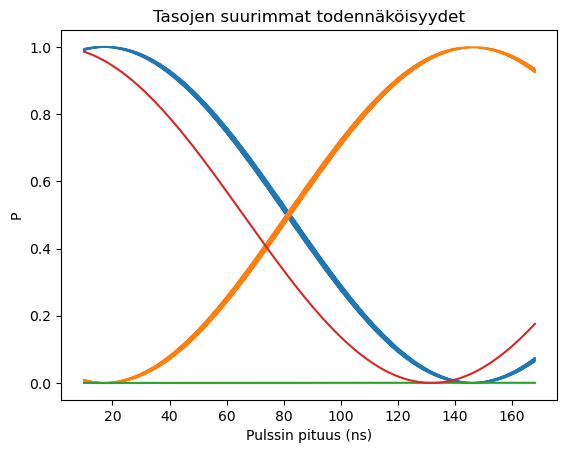

---------------------------------------------


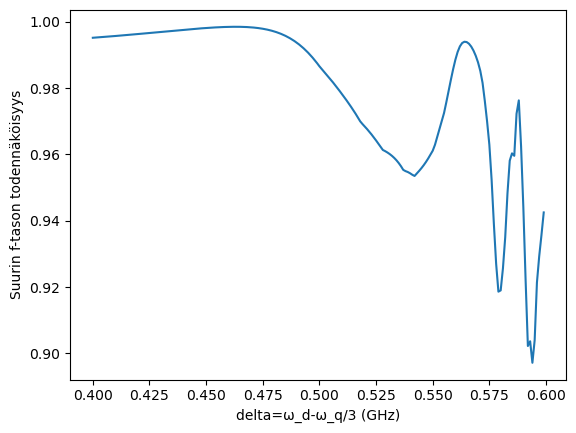

Amplitudi (GHz): 7.579505150034464
AC-stark siirtymä (GHz): 0.463
E-tason suurin todennäköisyys: 0.998736903943912
Pulssin pituus (ns): 114.96492584474474
Rabi-taajuus (fourier):  0.004569039799913539


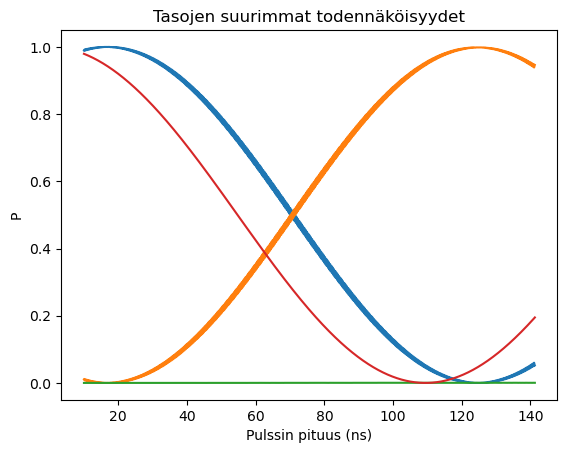

---------------------------------------------


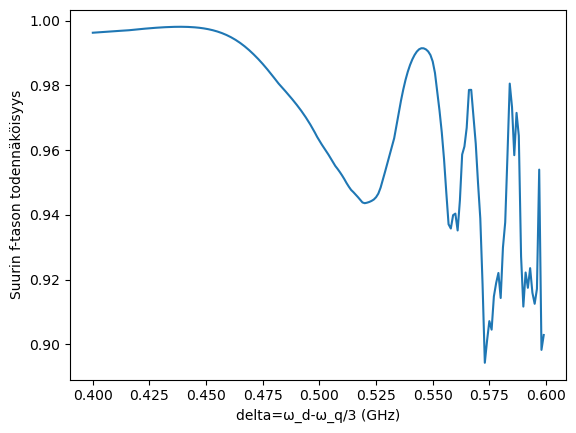

Amplitudi (GHz): 8.008786857647035
AC-stark siirtymä (GHz): 0.439
E-tason suurin todennäköisyys: 0.998355864432006
Pulssin pituus (ns): 103.12489321729177
Rabi-taajuus (fourier):  0.0054341388286923325


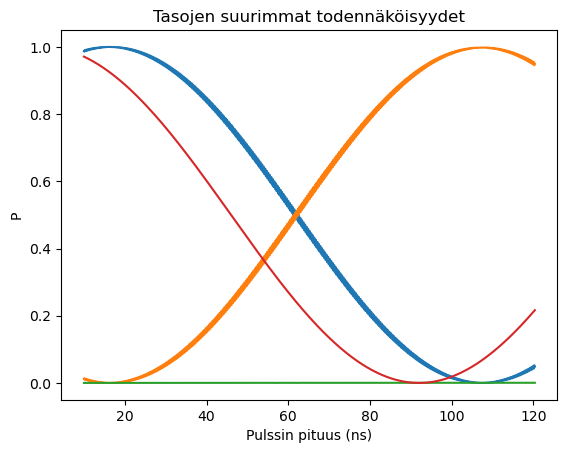

---------------------------------------------


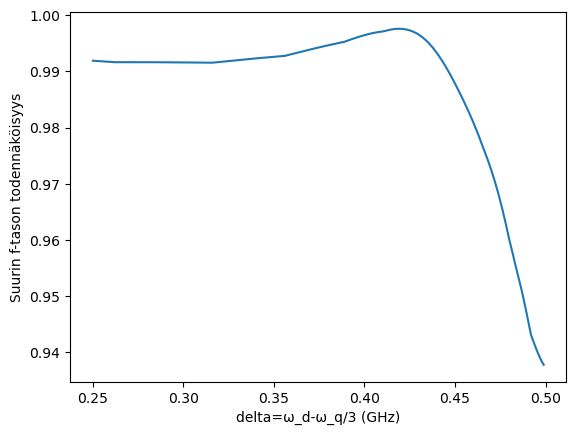

Amplitudi (GHz): 8.438068565259606
AC-stark siirtymä (GHz): 0.419
E-tason suurin todennäköisyys: 0.9979390832265136
Pulssin pituus (ns): 94.2617786613478
Rabi-taajuus (fourier):  0.006401883326317388


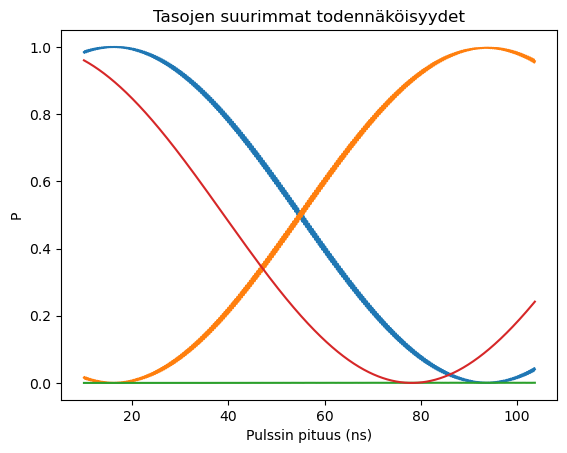

---------------------------------------------


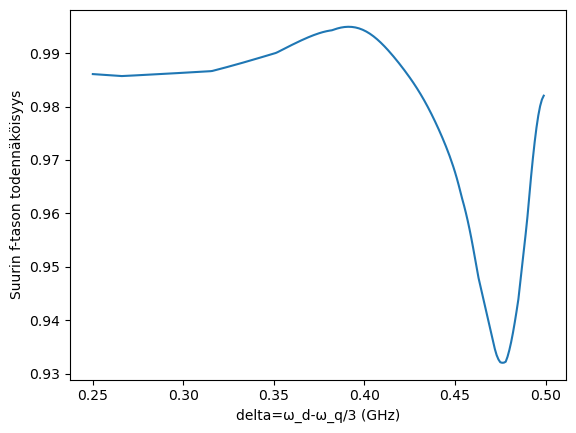

Amplitudi (GHz): 8.867350272872178
AC-stark siirtymä (GHz): 0.391
E-tason suurin todennäköisyys: 0.9954524762498771
Pulssin pituus (ns): 82.35995950255716
Rabi-taajuus (fourier):  0.007484911575017893


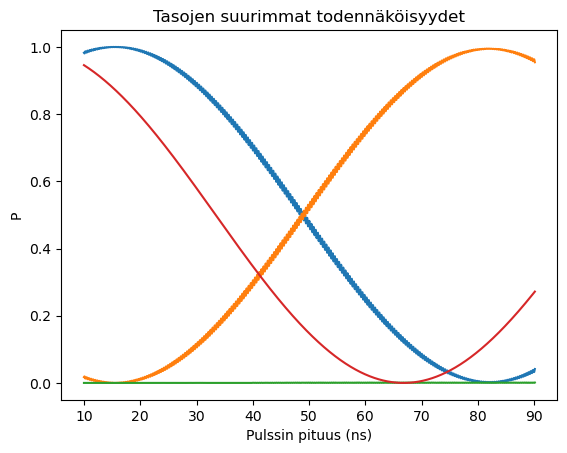

---------------------------------------------


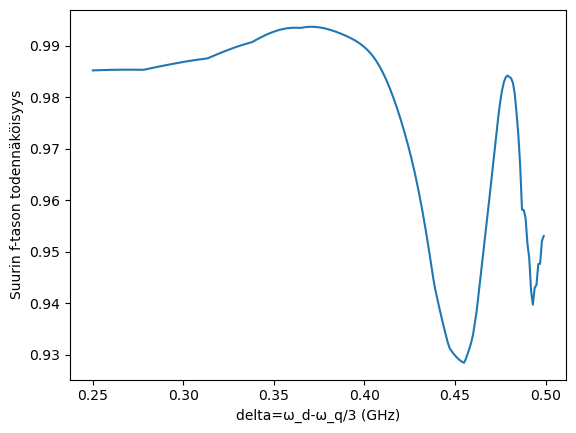

Amplitudi (GHz): 9.296631980484749
AC-stark siirtymä (GHz): 0.371
E-tason suurin todennäköisyys: 0.9940144211328041
Pulssin pituus (ns): 76.46474766209066
Rabi-taajuus (fourier):  0.008696765945476487


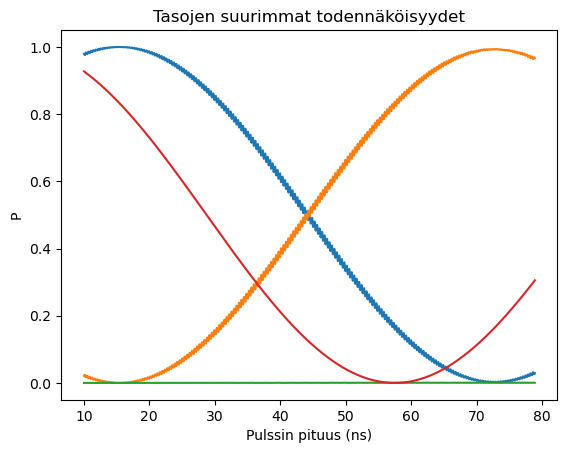

---------------------------------------------


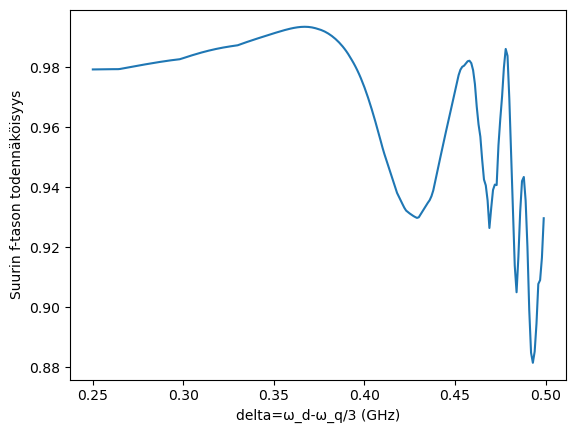

Amplitudi (GHz): 9.725913688097322
AC-stark siirtymä (GHz): 0.367
E-tason suurin todennäköisyys: 0.9946435673468665
Pulssin pituus (ns): 66.00971785733921
Rabi-taajuus (fourier):  0.01005032747661629


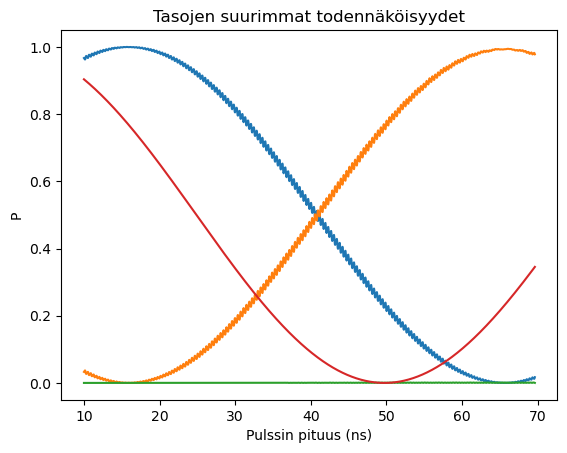

---------------------------------------------


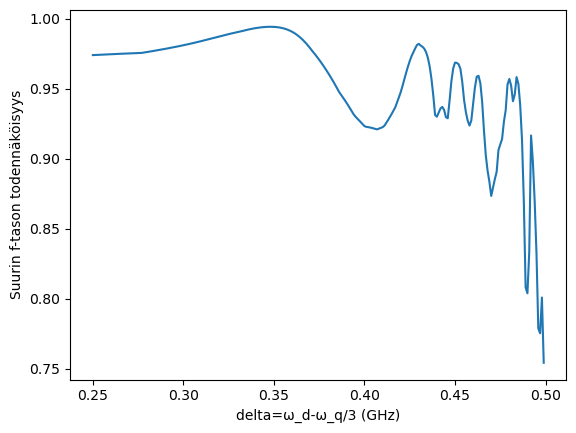

Amplitudi (GHz): 10.155195395709892
AC-stark siirtymä (GHz): 0.348
E-tason suurin todennäköisyys: 0.9958548914837416
Pulssin pituus (ns): 57.03310963298802
Rabi-taajuus (fourier):  0.01155826657020394


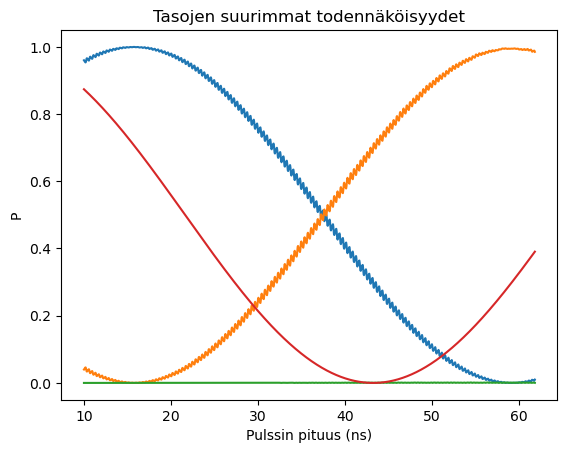

---------------------------------------------


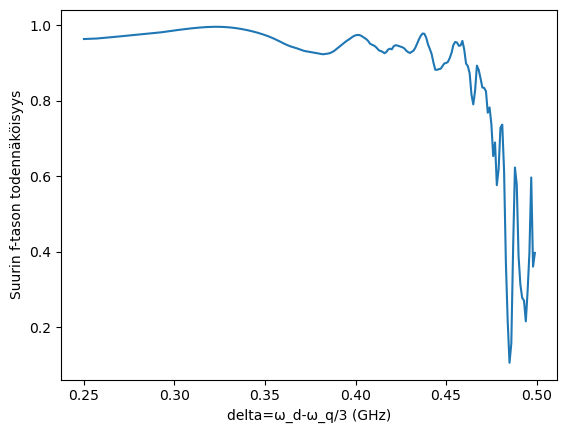

Amplitudi (GHz): 10.584477103322463
AC-stark siirtymä (GHz): 0.323
E-tason suurin todennäköisyys: 0.9966564116174188
Pulssin pituus (ns): 52.582667171186216
Rabi-taajuus (fourier):  0.013233600664636833


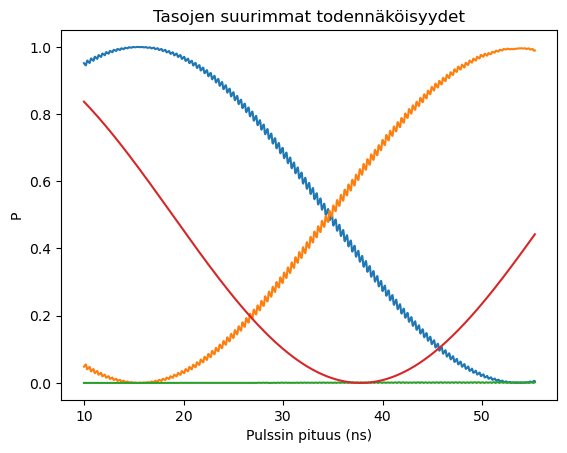

---------------------------------------------


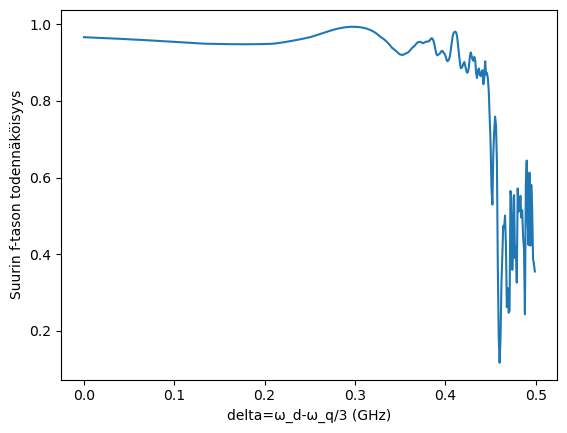

Amplitudi (GHz): 11.013758810935034
AC-stark siirtymä (GHz): 0.298
E-tason suurin todennäköisyys: 0.9947685877157038
Pulssin pituus (ns): 45.066597085006634
Rabi-taajuus (fourier):  0.015091051770899873


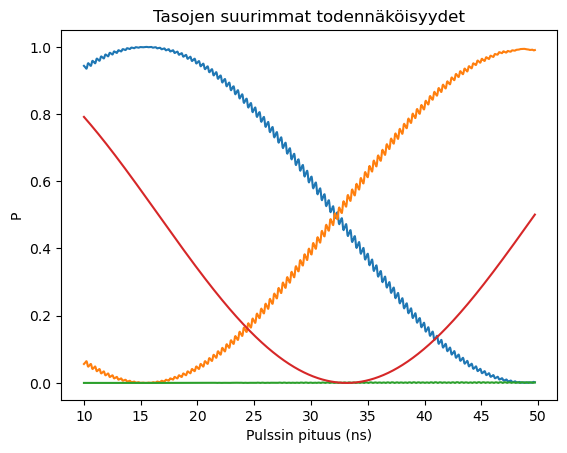

---------------------------------------------


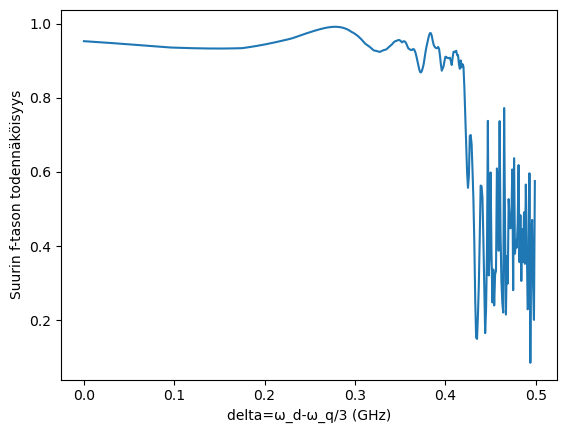

Amplitudi (GHz): 11.443040518547605
AC-stark siirtymä (GHz): 0.278
E-tason suurin todennäköisyys: 0.9956209107616862
Pulssin pituus (ns): 40.573510216363125
Rabi-taajuus (fourier):  0.01714146255805106


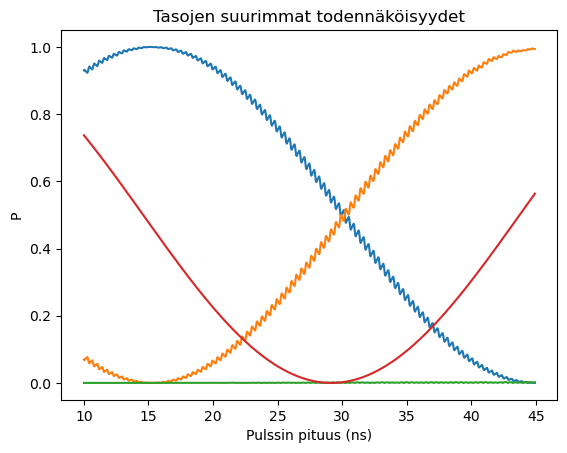

---------------------------------------------


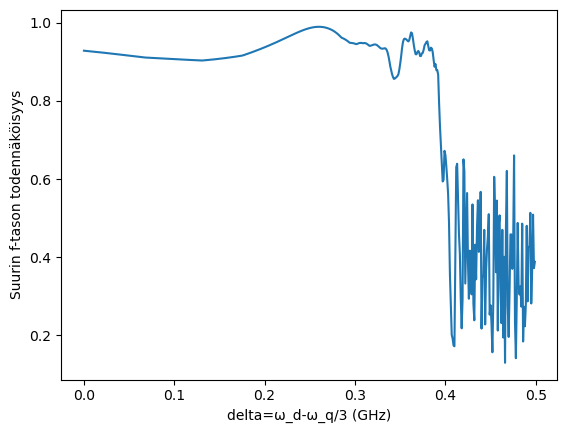

Amplitudi (GHz): 11.872322226160177
AC-stark siirtymä (GHz): 0.26
E-tason suurin todennäköisyys: 0.9966720502398673
Pulssin pituus (ns): 39.12541710324531
Rabi-taajuus (fourier):  0.019398374603633542


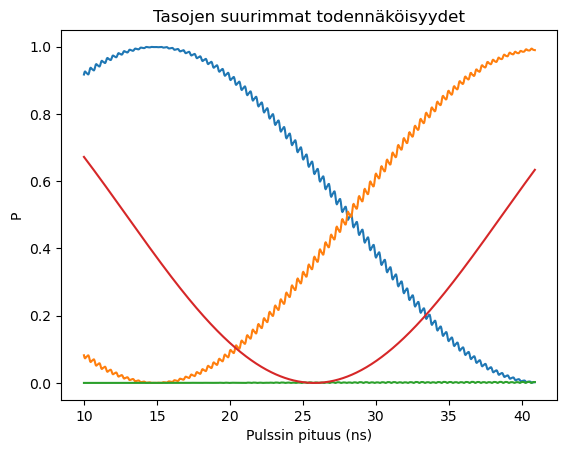

---------------------------------------------


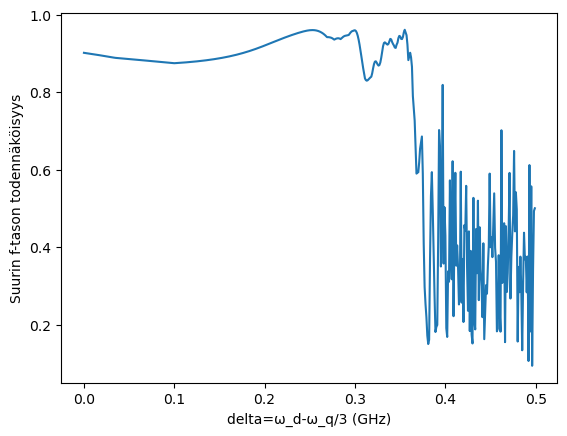

Amplitudi (GHz): 12.30160393377275
AC-stark siirtymä (GHz): 0.355
E-tason suurin todennäköisyys: 0.9699211400377461
Pulssin pituus (ns): 28.448787644184844
Rabi-taajuus (fourier):  0.021876095694201278


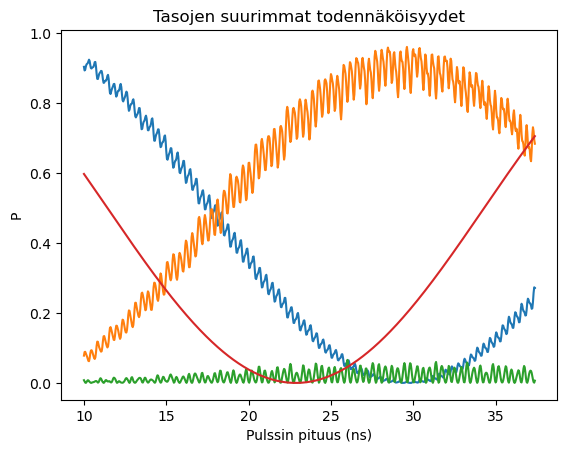

---------------------------------------------


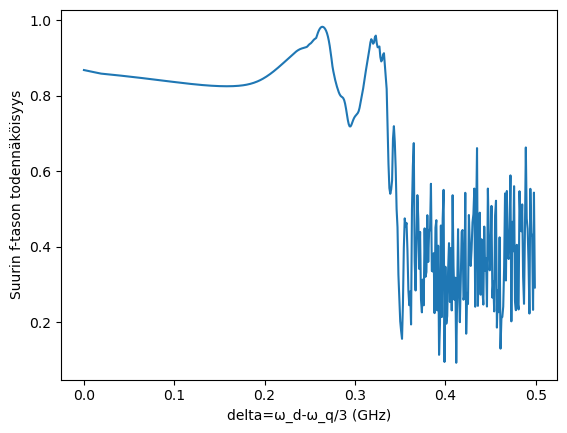

Amplitudi (GHz): 12.73088564138532
AC-stark siirtymä (GHz): 0.264
E-tason suurin todennäköisyys: 0.9849982566920955
Pulssin pituus (ns): 28.505743694555566
Rabi-taajuus (fourier):  0.024585680577181957


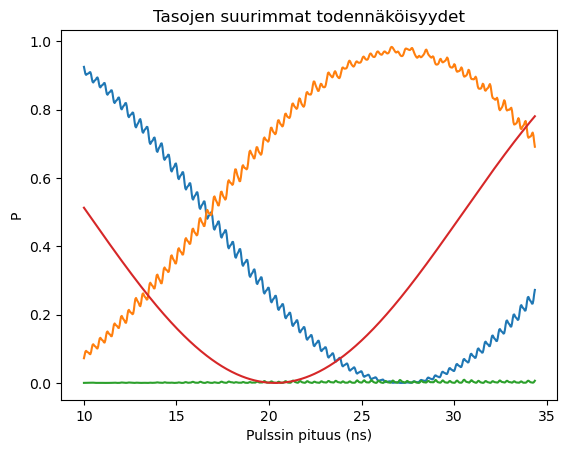

---------------------------------------------


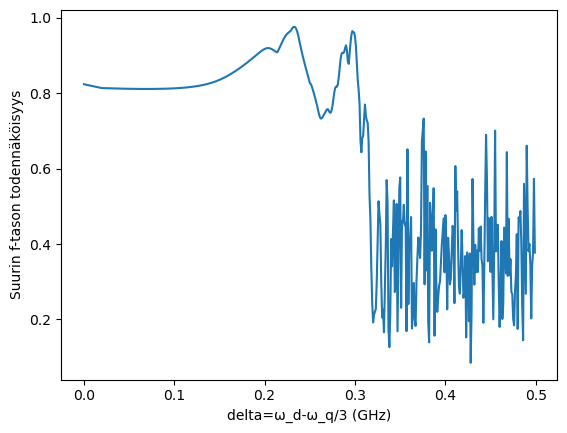

Amplitudi (GHz): 13.160167348997891
AC-stark siirtymä (GHz): 0.233
E-tason suurin todennäköisyys: 0.9893547421881171
Pulssin pituus (ns): 27.01708784235052
Rabi-taajuus (fourier):  0.027540951152082275


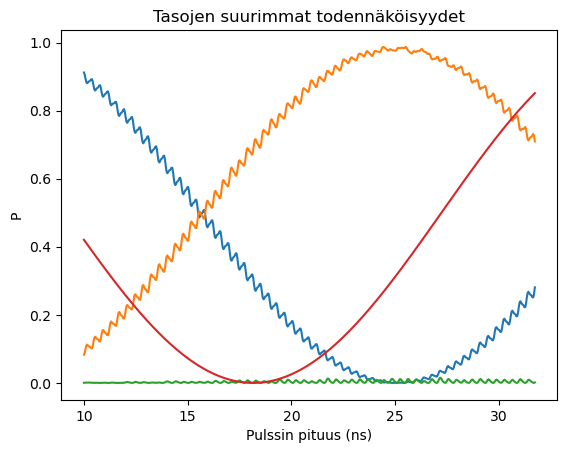

---------------------------------------------


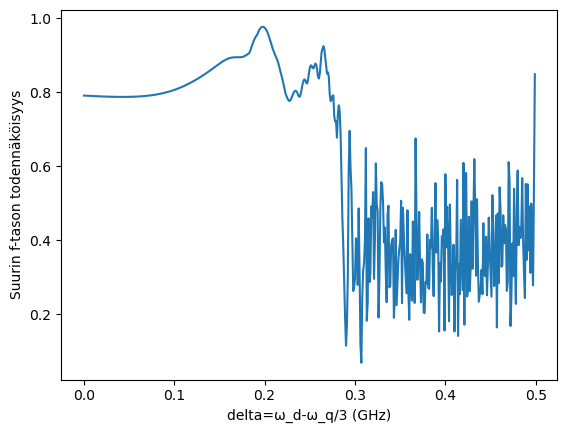

Amplitudi (GHz): 13.589449056610464
AC-stark siirtymä (GHz): 0.198
E-tason suurin todennäköisyys: 0.983290050644155
Pulssin pituus (ns): 23.969625668637033
Rabi-taajuus (fourier):  0.03075814196121034


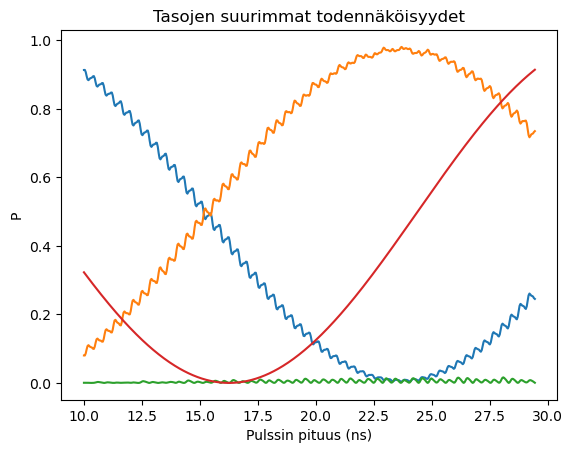

---------------------------------------------


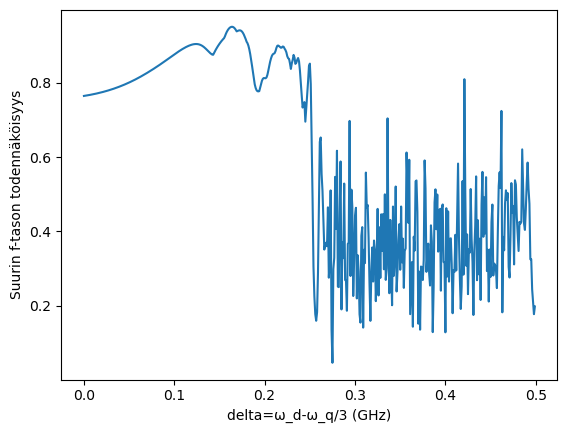

Amplitudi (GHz): 14.018730764223035
AC-stark siirtymä (GHz): 0.164
E-tason suurin todennäköisyys: 0.9695485797019238
Pulssin pituus (ns): 22.460581021046703
Rabi-taajuus (fourier):  0.034241313944029184


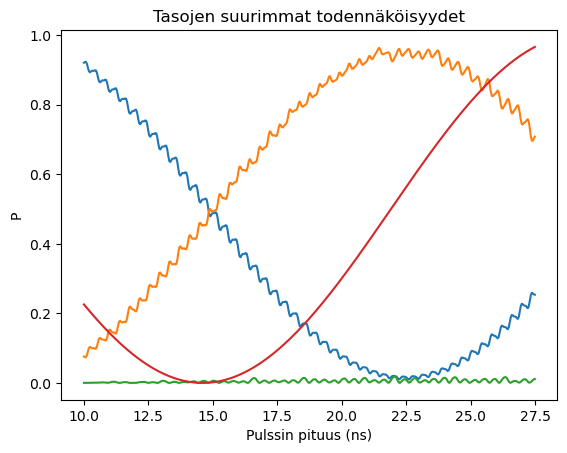

---------------------------------------------


In [7]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.23
max_range = 0.55
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_d_opt = qubit.frequency/3+list_AC_stark_vals[i] #Optimaalinen ajotaajuus

    f_rabi=2.875e-05*A**3 - 0.0003995*A**2 + 0.003097*A - 0.008257 #Arvaus Rabi-taajuudelle
    AC_stark=0 #Arvaus AC-stark siirtymälle
    if i < 6:
        params=find_params(f_d_opt, A, evolution_eigenbasis,f_rabi*10,AC_stark,[400,600],1000)
    elif i < 12:    
        params=find_params(f_d_opt, A, evolution_eigenbasis,f_rabi*10,AC_stark,[250,500],1000)
    else:
        params=find_params(f_d_opt, A, evolution_eigenbasis,f_rabi*10,AC_stark,[0,500],1000)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    m=10

    vals = pulses.sim_3_part_pulses(f_d_opt,f_ef/3+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi*10)/m,t_ramp=5,U_f=0,drag=True)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])
    
    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(5.862378319584177), np.float64(6.291660027196749), np.float64(6.720941734809321), np.float64(7.1502234424218925), np.float64(7.579505150034464), np.float64(8.008786857647035), np.float64(8.438068565259606), np.float64(8.867350272872178), np.float64(9.296631980484749), np.float64(9.725913688097322), np.float64(10.155195395709892), np.float64(10.584477103322463), np.float64(11.013758810935034), np.float64(11.443040518547605), np.float64(11.872322226160177), np.float64(12.30160393377275), np.float64(12.73088564138532), np.float64(13.160167348997891), np.float64(13.589449056610464), np.float64(14.018730764223035)]


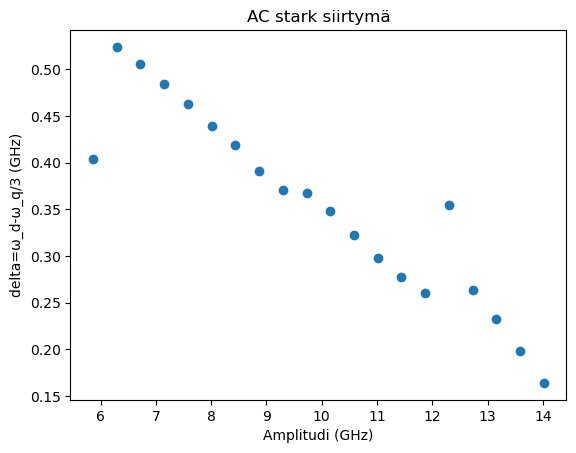

[0.404, 0.524, 0.506, 0.484, 0.463, 0.439, 0.419, 0.391, 0.371, 0.367, 0.348, 0.323, 0.298, 0.278, 0.26, 0.355, 0.264, 0.233, 0.198, 0.164]


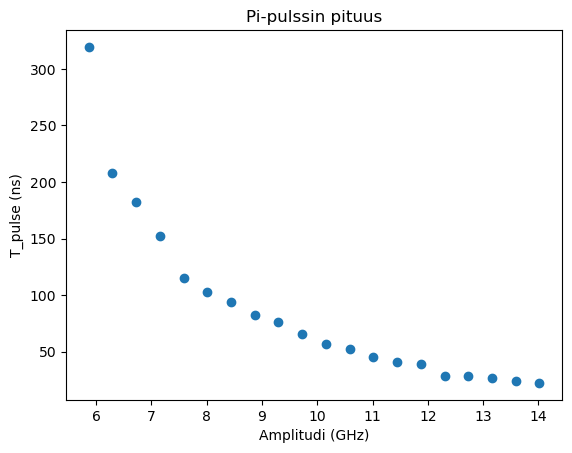

[np.float64(319.400691583002), np.float64(207.81812844429578), np.float64(181.92334746905524), np.float64(152.2304363672856), np.float64(114.96492584474474), np.float64(103.12489321729177), np.float64(94.2617786613478), np.float64(82.35995950255716), np.float64(76.46474766209066), np.float64(66.00971785733921), np.float64(57.03310963298802), np.float64(52.582667171186216), np.float64(45.066597085006634), np.float64(40.573510216363125), np.float64(39.12541710324531), np.float64(28.448787644184844), np.float64(28.505743694555566), np.float64(27.01708784235052), np.float64(23.969625668637033), np.float64(22.460581021046703)]


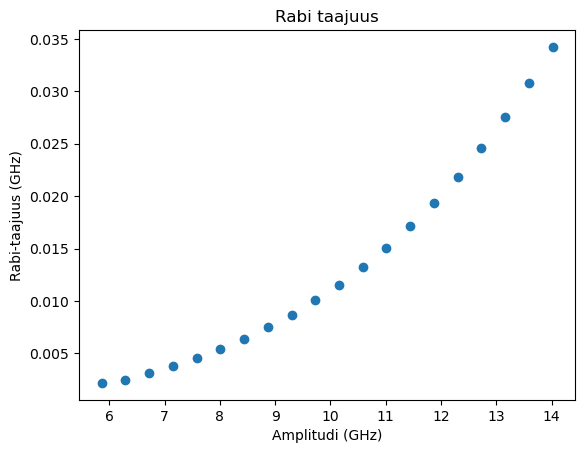

[np.float64(0.002185167692922755), np.float64(0.0024583838483561316), np.float64(0.0030942054261295865), np.float64(0.0037933515126451155), np.float64(0.004569039799913539), np.float64(0.0054341388286923325), np.float64(0.006401883326317388), np.float64(0.007484911575017893), np.float64(0.008696765945476487), np.float64(0.01005032747661629), np.float64(0.01155826657020394), np.float64(0.013233600664636833), np.float64(0.015091051770899873), np.float64(0.01714146255805106), np.float64(0.019398374603633542), np.float64(0.021876095694201278), np.float64(0.024585680577181957), np.float64(0.027540951152082275), np.float64(0.03075814196121034), np.float64(0.034241313944029184)]


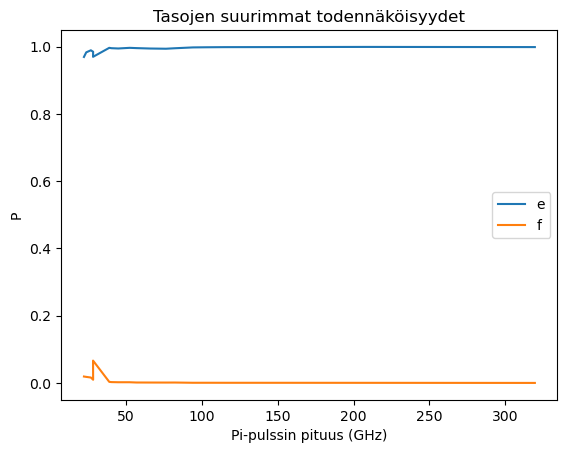

[np.float64(0.9989027111405493), np.float64(0.9993895170677627), np.float64(0.9992099337328575), np.float64(0.9989610158908179), np.float64(0.998736903943912), np.float64(0.998355864432006), np.float64(0.9979390832265136), np.float64(0.9954524762498771), np.float64(0.9940144211328041), np.float64(0.9946435673468665), np.float64(0.9958548914837416), np.float64(0.9966564116174188), np.float64(0.9947685877157038), np.float64(0.9956209107616862), np.float64(0.9966720502398673), np.float64(0.9699211400377461), np.float64(0.9849982566920955), np.float64(0.9893547421881171), np.float64(0.983290050644155), np.float64(0.9695485797019238)]
[np.float64(0.00011653969116851614), np.float64(0.0003932013263534713), np.float64(0.0004345354666285072), np.float64(0.00048106934422808406), np.float64(0.0005173799721699698), np.float64(0.0005938425958482956), np.float64(0.0005641619574039974), np.float64(0.0012742352368630577), np.float64(0.0011909389457887244), np.float64(0.001257016731307638), np.float64

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_d-ω_q/3 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)